<a href="https://colab.research.google.com/github/soumensen411/statistics-for-machine-learning/blob/main/Notebook/titanic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:
df = pd.read_csv(f'{path}/Titanic-Dataset.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df['Age'].isnull().sum()

np.int64(177)

In [ ]:
age = df['Age'].dropna()

# Q1: Calculate the mean, median, and mode of passenger ages. Are mean and median close? What does the gap tell you about the age distribution's skewness?

In [ ]:
print('mean : ', df['Age'].mean())
print('median : ', df['Age'].median())
print('mode : ', df['Age'].mode()[0])
print('skew: ',df['Age'].skew())

mean :  29.69911764705882
median :  28.0
mode :  24.0
skew:  0.38910778230082704


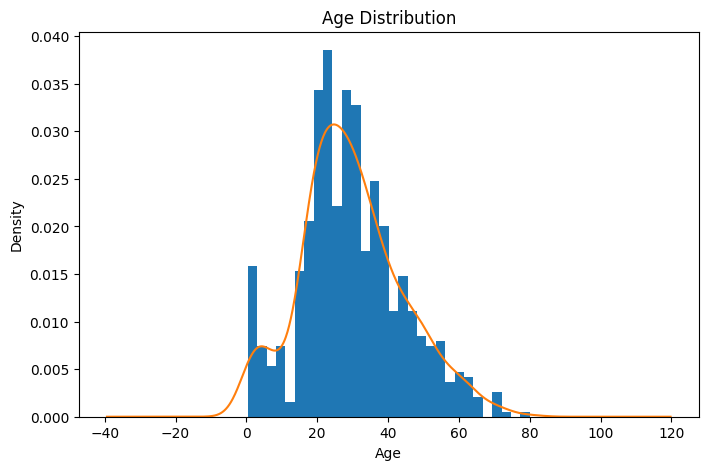

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(age,bins=30,density=True)
age.plot(kind='kde')
plt.title('Age Distribution')
plt.ylabel('Density')
plt.xlabel('Age')
plt.show()

The mean age 29.69 is higher than the median age 28.From figure it's clear age distribution are right skewed

# Q2.Compute the mean and standard deviation of Fare separately for each passenger class (Pclass). What does this tell you about the relationship between class and fare variability?

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df['Fare'].isnull().sum()

np.int64(0)

In [ ]:
fare = df['Fare'].dropna()

In [ ]:
mean_fare = fare.mean()
std_fare = fare.std()
var_fare = fare.var()
print('mean: ',mean_fare)
print('variance: ',var_fare)
print('standard Deviation: ',std_fare)


upper_bound = mean_fare + 2 * std_fare
outliers = df[df['Fare'] > upper_bound]
print(f"Outliers beyond 2σ: {len(outliers)}")

mean:  32.204207968574636
variance:  2469.436845743117
standard Deviation:  49.693428597180905
Outliers beyond 2σ: 38


In [ ]:
grouped = df.groupby('Pclass')['Fare'].agg(['mean','std'])
grouped

,mean,std
Pclass,,
1,84.154687,78.380373
2,20.662183,13.417399
3,13.675550,11.778142


In [ ]:
cv = grouped['std']/grouped['mean'] * 100
print(cv)

Pclass
1    93.138451
2    64.936985
3    86.125542
dtype: float64


# Q3. What is P(survived)? What is P(survived | female)? Is survival independent of sex? Justify with numbers.

P(A|B) = P(A ∩ B) / P(B)

In [40]:
total_survive = df['Survived'].mean()
male_survive = df[df['Sex']=='male']['Survived'].mean()
female_survive = df[df['Sex'] == 'female']['Survived'].mean()
print(f"Total survive :  {total_survive:.2f}")
print(f"Female survive : {female_survive:.2f}")
print(f"Male survive :  {male_survive:.2f}")

Total survive :  0.38
Female survive : 0.74
Male survive :  0.19


In [41]:
print(f"P(survived)         = {total_survive:.3f}")
print(f"P(survived|female)  = {female_survive:.3f}")
print(f"P(survived|male)    = {male_survive:.3f}")

P(survived)         = 0.384
P(survived|female)  = 0.742
P(survived|male)    = 0.189


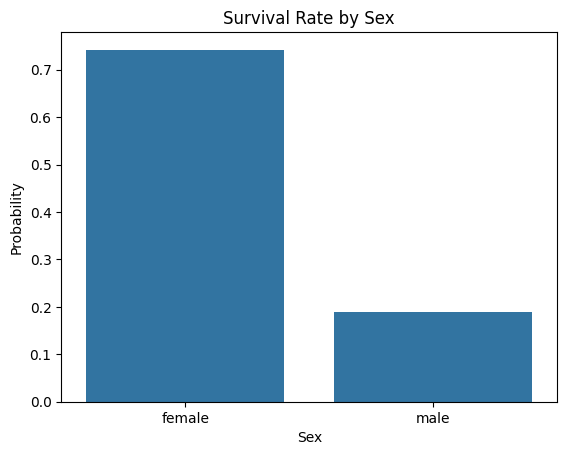

In [47]:
plot_data = df.groupby('Sex')['Survived'].mean()
sns.barplot(plot_data)
plt.title('Survival Rate by Sex')
plt.ylabel('Probability')
plt.show()

The overall survival probability is around 0.38, while the survival probability for females is significantly higher (~0.74) compared to males (~0.19). Since these probabilities differ greatly, survival is not independent of sex. This indicates that gender had a strong influence on survival outcomes.